# Modal frequencies — acceleration in X and Y

10 sensors from `test1`. Two separate tables, from two separate data sources:

1. **Geophone-derived acceleration** — the geophone (`Vx`, `Vy`, `Vz`) signal
   differentiated, `a = dv/dt`.
2. **Raw MEMS acceleration** — the `Ax`, `Ay`, `Az` channels straight from the
   `.bin` file, no transformation.

Same method for both: FFT of the 10 sensors combined via SVD, peaks above
`PROMINENCE`. Frequencies closer than `TOL_HZ` in X and Y share a `Mode` number.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import get_window, detrend, find_peaks, welch

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "legend.frameon": False, "font.size": 9.5})

DATA_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Raw_Data\jakobsplan_sensors\test1"
POST_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data"

NPERSEG    = 16384      # frequency resolution = fs/NPERSEG ~ 0.024 Hz
FMIN, FMAX = 0.8, 25.0  # analysis band
PROMINENCE = 5          # minimum dB for a mode to be detected
TOL_HZ     = 0.35       # frequencies closer than this are the same mode

RAMP = {"X": LinearSegmentedColormap.from_list("b", ["#9ec5f4", "#2a78d6", "#0d366b"]),
        "Y": LinearSegmentedColormap.from_list("o", ["#f6c3a8", "#eb6834", "#7a2e10"])}

print("Configuration loaded.")

Configuration loaded.


In [2]:
COLS = ["Vx", "Vy", "Vz", "Ax", "Ay", "Az"]
FILES = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".bin")],
               key=lambda s: int(re.search(r"sensor(\d+)", s).group(1)))


def load_file(path, channel):
    with open(path, "rb") as f:
        raw = f.read()
    end = raw.find(b"\r\n\r\n") + 4
    info = {}
    for line in raw[:end].decode("ascii", errors="ignore").splitlines():
        if ":" in line:
            k, v = line.split(":", 1)
            info[k.strip()] = v.strip()
    b = np.frombuffer(raw[end:], dtype=np.uint8).reshape(-1, 3)
    val = (b[:, 0].astype(np.int32) | (b[:, 1].astype(np.int32) << 8)
           | (b[:, 2].astype(np.int32) << 16))
    val = (val ^ (1 << 23)) - (1 << 23)                    # signed 24 bit
    n = (len(val) // 6) * 6
    x = val[:n].reshape(-1, 6)[:, COLS.index(channel)].astype(float)
    return x, float(info["Sampling Frequency (Hz)"]), info


def geophone_acceleration_10_sensors(geophone_channel):
    """10-sensor matrix, geophone signal differentiated: a = dv/dt."""
    sig, sens = [], []
    axis = {"Vx": 0, "Vy": 1, "Vz": 2}[geophone_channel]
    for fn in FILES:
        x, fs, info = load_file(os.path.join(DATA_DIR, fn), geophone_channel)
        sig.append(x)
        sens.append(float(info["Geophone"].split(",")[3 * axis]))
    n = min(len(s) for s in sig)
    X = detrend(np.column_stack([s[:n] for s in sig]), axis=0, type="constant")
    X = X / np.array(sens)                     # equalise the 10 sensors
    return np.gradient(X, 1 / fs, axis=0), fs  # velocity -> acceleration


def mems_acceleration_10_sensors(mems_channel):
    """10-sensor matrix, raw MEMS channel as stored in the .bin, no transformation."""
    sig = []
    for fn in FILES:
        x, fs, info = load_file(os.path.join(DATA_DIR, fn), mems_channel)
        sig.append(x)
    n = min(len(s) for s in sig)
    X = detrend(np.column_stack([s[:n] for s in sig]), axis=0, type="constant")
    return X, fs


def mode_frequencies(X, fs, spec_key):
    """Mode frequencies from the combined spectrum (SVD) of the 10 sensors."""
    npg, nch = NPERSEG, X.shape[1]
    win = get_window("hann", npg)
    step = npg // 2
    nseg = 1 + (len(X) - npg) // step

    G = np.zeros((npg // 2 + 1, nch, nch), dtype=complex)
    for k in range(nseg):
        seg = detrend(X[k * step: k * step + npg], axis=0, type="constant") * win[:, None]
        F = np.fft.rfft(seg, axis=0)                # FFT of the 10 sensors
        G += F[:, :, None] * np.conj(F[:, None, :])
    G *= 1 / (fs * (win ** 2).sum() * nseg)
    f = np.fft.rfftfreq(npg, 1 / fs)
    m = (f >= FMIN) & (f <= FMAX)
    f = f[m]
    sv1 = np.linalg.svd(G[m], compute_uv=False)[:, 0]
    db = 10 * np.log10(sv1)
    SPEC[spec_key] = (f, db)
    pk, _ = find_peaks(db, prominence=PROMINENCE,
                       distance=max(1, int(0.10 / (f[1] - f[0]))))
    return [round(float(f[i]), 3) for i in pk]


def build_table(freqs_by_dir):
    """Groups frequencies into modes and lays out X / Y side by side."""
    rows = [{"Direction": d, "f [Hz]": v} for d in freqs_by_dir for v in freqs_by_dir[d]]
    uni = pd.DataFrame(rows).sort_values("f [Hz]").reset_index(drop=True)

    mode, current, seen = [], 1, set()
    for i in range(len(uni)):
        d = uni.loc[i, "Direction"]
        if i and (uni.loc[i, "f [Hz]"] - uni.loc[i - 1, "f [Hz]"] > TOL_HZ or d in seen):
            current += 1
            seen = set()
        seen.add(d)
        mode.append(current)
    uni.insert(0, "Mode", mode)

    table = (uni.groupby(["Mode", "Direction"])["f [Hz]"]
                .apply(lambda v: " / ".join(f"{x:.3f}" for x in sorted(v)))
                .unstack("Direction")
                .reindex(columns=["X", "Y"])
                .fillna("—"))
    table.columns = ["f in X [Hz]", "f in Y [Hz]"]
    return table


SPEC = {}
print("Functions loaded.")

Functions loaded.


## Table 1 — geophone-derived acceleration (a = dv/dt)

In [3]:
X_geo = {"X": geophone_acceleration_10_sensors("Vx"), "Y": geophone_acceleration_10_sensors("Vy")}
freqs_geo = {d: mode_frequencies(X_geo[d][0], X_geo[d][1], f"geo_{d}") for d in X_geo}
table_geo = build_table(freqs_geo)

print(f"{sum(len(v) for v in freqs_geo.values())} frequencies -> {len(table_geo)} modes\n")
display(table_geo)

path = os.path.join(POST_DIR, "test1_modes_XY_geophone.csv")
table_geo.to_csv(path)
print("\nCSV:", path)

16 frequencies -> 12 modes



,f in X [Hz],f in Y [Hz]
Mode,,
1,2.023,1.951
2,2.625,—
3,2.866,—
4,3.540,3.275
5,4.937,4.937
6,5.973,—
7,7.466,7.345
8,—,11.102
9,12.330,—



CSV: C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data\test1_modes_XY_geophone.csv


## Table 2 — raw MEMS acceleration (Ax, Ay)

In [4]:
X_mems = {"X": mems_acceleration_10_sensors("Ax"), "Y": mems_acceleration_10_sensors("Ay")}
freqs_mems = {d: mode_frequencies(X_mems[d][0], X_mems[d][1], f"mems_{d}") for d in X_mems}
table_mems = build_table(freqs_mems)

print(f"{sum(len(v) for v in freqs_mems.values())} frequencies -> {len(table_mems)} modes\n")
display(table_mems)

path = os.path.join(POST_DIR, "test1_modes_XY_mems.csv")
table_mems.to_csv(path)
print("\nCSV:", path)

2 frequencies -> 1 modes



,f in X [Hz],f in Y [Hz]
Mode,,
1,2.023,1.951



CSV: C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data\test1_modes_XY_mems.csv


### Spectrum of the 10 sensors — geophone-derived acceleration

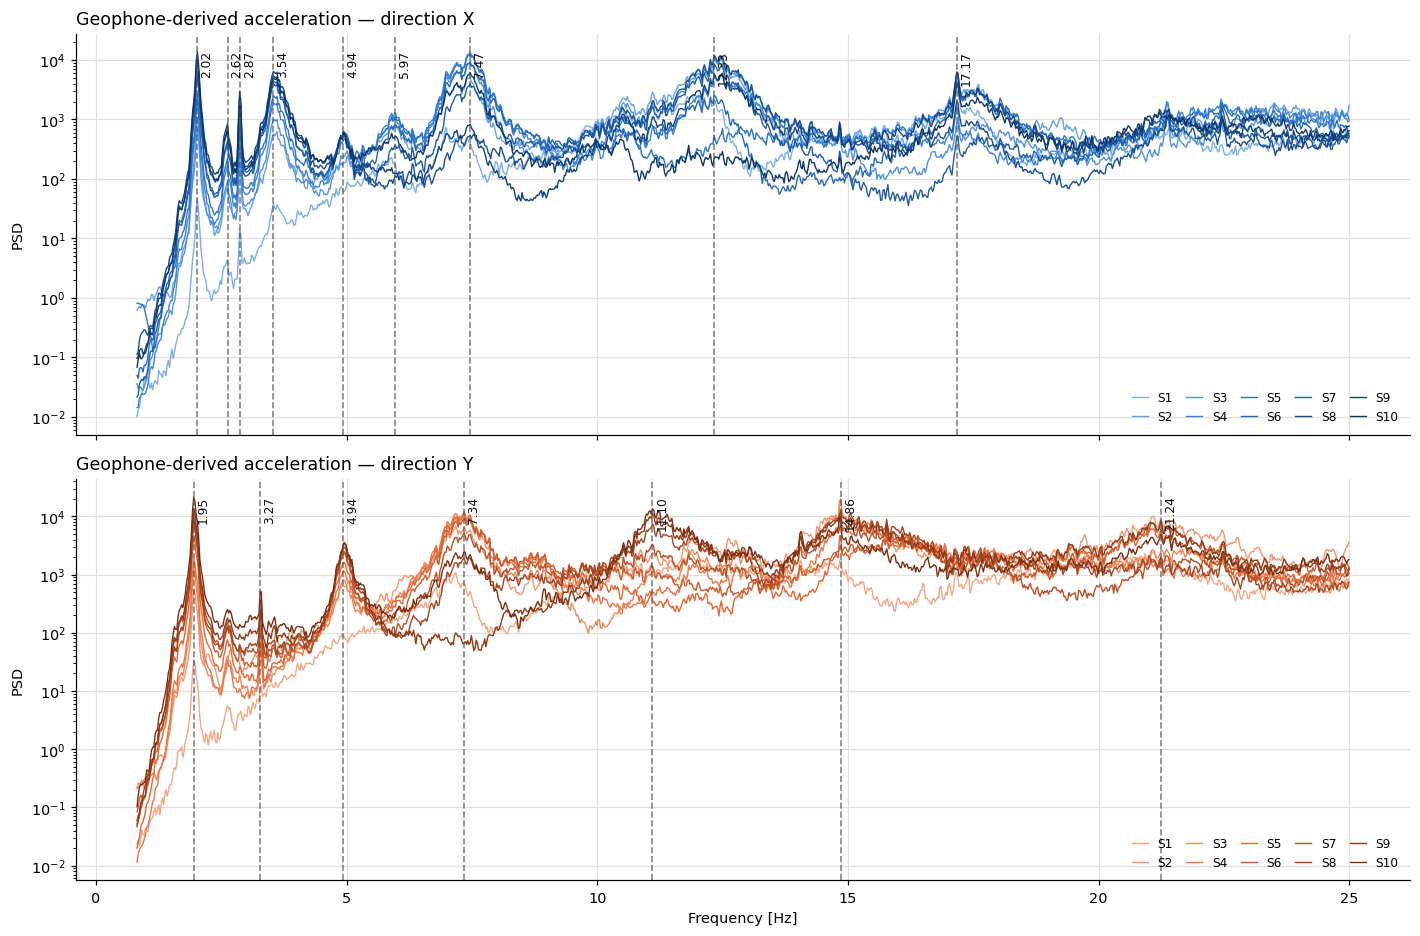

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.6), sharex=True)

for ax, d in zip(axes, ["X", "Y"]):
    X, fs = X_geo[d]
    colors = RAMP[d](np.linspace(0.15, 1.0, X.shape[1]))
    for k in range(X.shape[1]):
        fw, Pw = welch(X[:, k], fs=fs, nperseg=NPERSEG)
        m = (fw >= FMIN) & (fw <= FMAX)
        ax.semilogy(fw[m], Pw[m], color=colors[k], linewidth=0.9, label=f"S{k+1}")
    for v in freqs_geo[d]:
        ax.axvline(v, color="#52514e", linestyle="--", linewidth=1.1, alpha=0.7)
        ax.annotate(f"{v:.2f}", (v, ax.get_ylim()[1]), xytext=(2, -11),
                    textcoords="offset points", fontsize=8, color="#0b0b0b",
                    rotation=90, va="top")
    ax.set_ylabel("PSD")
    ax.set_title(f"Geophone-derived acceleration — direction {d}", loc="left")
    ax.legend(ncol=5, loc="lower right", columnspacing=1.1, handlelength=1.3, fontsize=8)

axes[1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

### Spectrum of the 10 sensors — raw MEMS acceleration

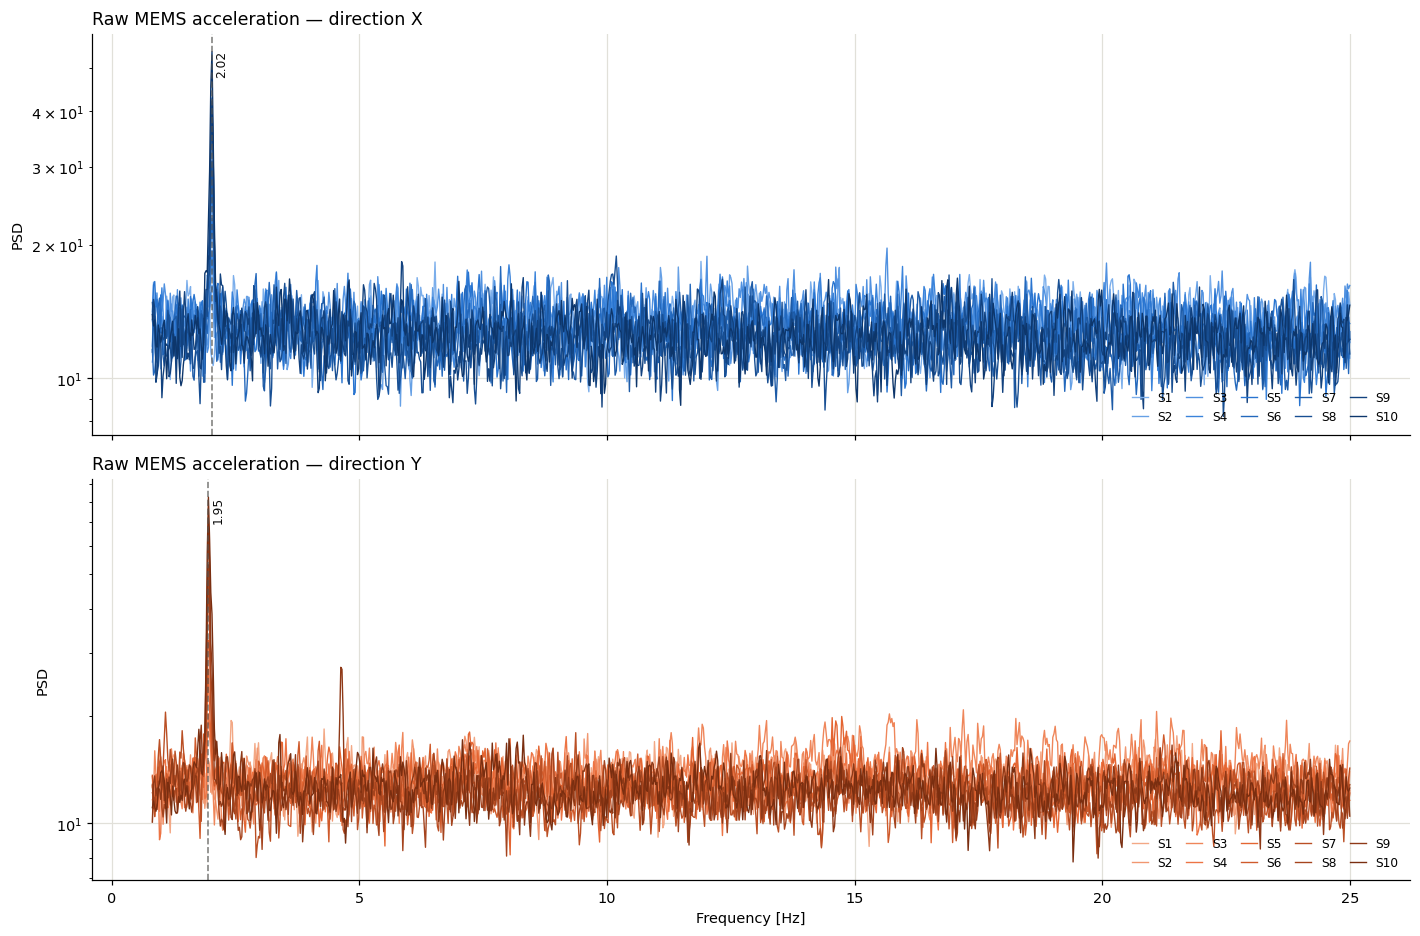

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.6), sharex=True)

for ax, d in zip(axes, ["X", "Y"]):
    X, fs = X_mems[d]
    colors = RAMP[d](np.linspace(0.15, 1.0, X.shape[1]))
    for k in range(X.shape[1]):
        fw, Pw = welch(X[:, k], fs=fs, nperseg=NPERSEG)
        m = (fw >= FMIN) & (fw <= FMAX)
        ax.semilogy(fw[m], Pw[m], color=colors[k], linewidth=0.9, label=f"S{k+1}")
    for v in freqs_mems[d]:
        ax.axvline(v, color="#52514e", linestyle="--", linewidth=1.1, alpha=0.7)
        ax.annotate(f"{v:.2f}", (v, ax.get_ylim()[1]), xytext=(2, -11),
                    textcoords="offset points", fontsize=8, color="#0b0b0b",
                    rotation=90, va="top")
    ax.set_ylabel("PSD")
    ax.set_title(f"Raw MEMS acceleration — direction {d}", loc="left")
    ax.legend(ncol=5, loc="lower right", columnspacing=1.1, handlelength=1.3, fontsize=8)

axes[1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.show()